In [55]:
import pandas as pd
import numpy as np
import joblib
import xgboost as xgb
import os
import random
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, LSTM, Dense, Masking, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"


In [56]:
df15 = pd.read_csv(r"D:\CongTyObiuty\2. DuAn\3. ThayCong\2. Obiuty\2. AiData\Database\training\ai_churntrain_H15_2026-01-01.csv", parse_dates=["syncdate"])
df30 = pd.read_csv(r"D:\CongTyObiuty\2. DuAn\3. ThayCong\2. Obiuty\2. AiData\Database\training\ai_churntrain_H30_2026-01-01.csv", parse_dates=["syncdate"])
# df45 = pd.read_csv(r"D:\CongTyObiuty\2. DuAn\3. ThayCong\2. Obiuty\2. AiData\Database\training\ai_churntrain_H45_2026-01-01.csv", parse_dates=["syncdate"])

def remove_invalid_remainingpoint(df):
    before = len(df)
    df = df[df["remainingpoint"] >= 0].copy()
    after = len(df)

    print(f"Removed {before - after} rows with remainingpoint < 0")
    return df

df15 = remove_invalid_remainingpoint(df15)
df30 = remove_invalid_remainingpoint(df30)
# df45 = remove_invalid_remainingpoint(df45)

FEATURE_COLS = [
    c for c in df15.columns
    if c not in ["syncdate", "spbiid","churnwindow","returnamount","delaybinnoise","lastordertime","nextdays", "ischurn"]
]

def time_split_df(df, ratio=0.8):
    df = df.sort_values("syncdate").reset_index(drop=True)

    split_idx = int(len(df) * ratio)

    train_df = df.iloc[:split_idx].copy()
    test_df  = df.iloc[split_idx:].copy()

    return train_df, test_df


df15_tr, df15_te = time_split_df(df15)
df30_tr, df30_te = time_split_df(df30)
# df45_tr, df45_te = time_split_df(df45)


# Khởi tạo scaler
scaler = StandardScaler()
scaler_30 = StandardScaler()
# scaler_45 = StandardScaler()

# Fit trên lịch sử tương ứng
scaler.fit(df15_tr[FEATURE_COLS])
scaler_30.fit(df30_tr[FEATURE_COLS])
# scaler_45.fit(df45_tr[FEATURE_COLS])


df15_tr[FEATURE_COLS] = scaler.transform(df15_tr[FEATURE_COLS])
df15_te[FEATURE_COLS] = scaler.transform(df15_te[FEATURE_COLS])
df30_tr[FEATURE_COLS] = scaler_30.transform(df30_tr[FEATURE_COLS])
df30_te[FEATURE_COLS] = scaler_30.transform(df30_te[FEATURE_COLS])
# df45_tr[FEATURE_COLS] = scaler_45.transform(df45_tr[FEATURE_COLS])
# df45_te[FEATURE_COLS] = scaler_45.transform(df45_te[FEATURE_COLS])

df_lstm = df15_tr.drop(columns=["ischurn"])
df_lstm_30 = df30_tr.drop(columns=["ischurn"])
# df_lstm_45 = df45_tr.drop(columns=["ischurn"])


Removed 22 rows with remainingpoint < 0
Removed 17 rows with remainingpoint < 0


C:\Users\nguye\AppData\Local\Temp\ipykernel_14228\3213129929.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df15 = pd.read_csv(r"D:\CongTyObiuty\2. DuAn\3. ThayCong\2. Obiuty\2. AiData\Database\training\ai_churntrain_H15_2026-01-01.csv", parse_dates=["syncdate"])
C:\Users\nguye\AppData\Local\Temp\ipykernel_14228\3213129929.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df30 = pd.read_csv(r"D:\CongTyObiuty\2. DuAn\3. ThayCong\2. Obiuty\2. AiData\Database\training\ai_churntrain_H30_2026-01-01.csv", parse_dates=["syncdate"])


In [57]:
df15_tr

,syncdate,spbiid,totalcompleted,copoorder,incopoorder,ordercycletime,copoavg,startpercent,curpercent,uplevelamount,...,eventtotalearned,corpominuspoint,remainingpoint,spccid,delaybinnoise,lastordertime,returnamount,churnwindow,ischurn,nextdays
0,1735664400,17452,1.622488,0.935909,2.580861,-0.455695,-0.455801,-0.726430,-0.231499,2.830128,...,-0.448247,-0.077467,-0.557163,0.198004,0.41,1733986800,1,60,0,15
1,1735664400,28034,0.192739,0.183645,0.129477,-0.507693,1.239586,-0.726430,0.799049,1.610744,...,-0.448247,-0.077467,-0.557163,1.654402,0.90,1732327200,0,60,0,15
2,1735664400,28025,0.192739,0.183645,0.129477,-0.525019,0.087109,-0.726430,-0.231499,0.391361,...,-0.448247,-0.077467,-0.557163,0.198004,1.28,1732064400,0,60,0,15
3,1735664400,22977,-0.624261,-0.568619,-0.483369,-0.263212,-0.475673,1.433782,0.799049,-0.828023,...,-0.448247,-0.077467,-0.557163,0.198004,3.89,1722308400,0,60,1,15
4,1735664400,16599,-0.011511,0.183645,-0.483369,-0.416952,1.727587,-0.726430,0.799049,1.610744,...,-0.448247,-0.077467,-0.557163,0.198004,1.67,1730854800,0,60,0,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21394,1763139600,33392,-0.624261,-0.568619,-0.483369,0.024137,-0.045065,-0.726430,-1.262047,-0.828023,...,-0.448247,-0.077467,-0.331283,0.198004,5.02,1740458460,0,60,1,15
21395,1763139600,33484,-0.011511,0.183645,-0.483369,0.451714,1.736638,0.353676,0.799049,0.391361,...,0.969678,-0.077467,-0.039661,0.198004,0.69,1758877200,1,60,0,15
21396,1763139600,33378,-0.215761,-0.067109,-0.483369,-0.556031,0.317198,0.353676,-0.231499,-0.828023,...,0.969678,-0.077467,1.458901,0.198004,7.80,1745031600,0,60,1,15
21397,1763139600,33400,-0.624261,-0.568619,-0.483369,0.024137,-0.650660,0.353676,-0.231499,-0.828023,...,-0.448247,-0.077467,-0.280712,0.198004,5.03,1740379440,0,60,1,15


In [58]:
FEATURE_COLS

['totalcompleted',
 'copoorder',
 'incopoorder',
 'ordercycletime',
 'copoavg',
 'startpercent',
 'curpercent',
 'uplevelamount',
 'uplevelstatus',
 'requestdocamount',
 'responseamount',
 'resultamount',
 'call60damount',
 'calllaodamount',
 'aftlastduavg',
 'bef60dduavg',
 'befpnhashamount',
 'beflaodahashamount',
 'trantotalearned',
 'eventtotalearned',
 'corpominuspoint',
 'remainingpoint',
 'spccid']

In [59]:
for name, df in [("15d", df15), ("30d", df30)]:
    print(f"\n{name}")
    print(df["ischurn"].value_counts(normalize=True) * 100)



15d
ischurn
1    64.701484
0    35.298516
Name: proportion, dtype: float64

30d
ischurn
1    69.790425
0    30.209575
Name: proportion, dtype: float64


In [60]:
def snapshot_distribution(df, name=""):
    # Đếm số snapshot của mỗi khách
    snapshot_cnt = (
        df.groupby("spbiid")
          .size()
          .reset_index(name="n_snapshot")
    )

    # Phân loại
    result = {
        "1 snapshot": (snapshot_cnt["n_snapshot"] == 1).sum(),
        "2 snapshot": (snapshot_cnt["n_snapshot"] == 2).sum(),
        "3 snapshot": (snapshot_cnt["n_snapshot"] == 3).sum(),
        "4 snapshot": (snapshot_cnt["n_snapshot"] == 4).sum(),
        ">= 4 snapshot": (snapshot_cnt["n_snapshot"] >= 4).sum(),
        "total customers": snapshot_cnt.shape[0]
    }

    print(f"\n===== {name} =====")
    for k, v in result.items():
        print(f"{k:15}: {v}")

    return snapshot_cnt
snap_15 = snapshot_distribution(df15, "H15 (15 days)")
snap_30 = snapshot_distribution(df30, "H30 (30 days)")
# snap_45 = snapshot_distribution(df45, "H45 (45 days)")



===== H15 (15 days) =====
1 snapshot     : 33
2 snapshot     : 22
3 snapshot     : 35
4 snapshot     : 34
>= 4 snapshot  : 1382
total customers: 1472

===== H30 (30 days) =====
1 snapshot     : 30
2 snapshot     : 26
3 snapshot     : 41
4 snapshot     : 28
>= 4 snapshot  : 1347
total customers: 1444


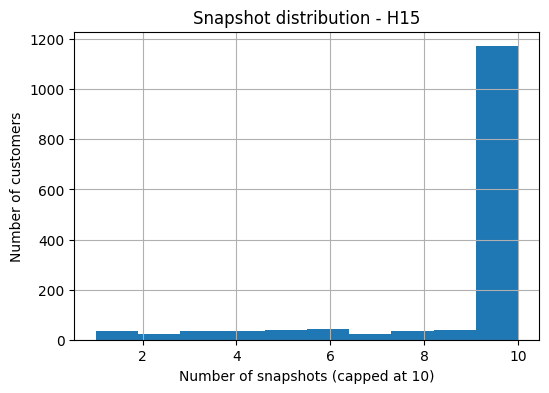

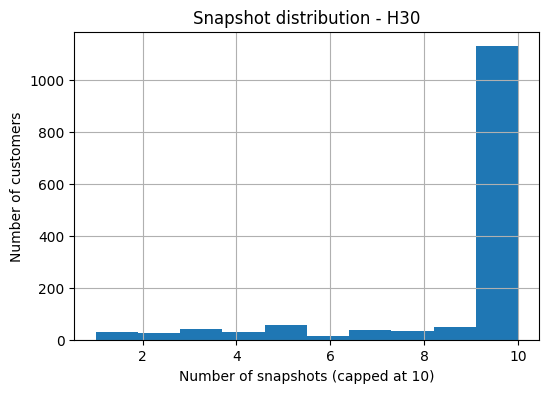

In [61]:
import matplotlib.pyplot as plt

def plot_snapshot_hist(snapshot_cnt, name=""):
    plt.figure(figsize=(6,4))
    snapshot_cnt["n_snapshot"].clip(upper=10).hist(bins=10)
    plt.title(f"Snapshot distribution - {name}")
    plt.xlabel("Number of snapshots (capped at 10)")
    plt.ylabel("Number of customers")
    plt.show()

plot_snapshot_hist(snap_15, "H15")
plot_snapshot_hist(snap_30, "H30")
# plot_snapshot_hist(snap_45, "H45")


In [62]:


def build_sequences(df, feature_cols, max_steps):
    X_seq, X_last, y = [], [], []

    for _, g in df.groupby("spbiid"):
        g = g.sort_values("syncdate")
        seq = g[feature_cols].values.astype("float32")

        for i in range(len(seq)):
            hist = seq[max(0, i - max_steps + 1): i + 1]

            X_seq.append(hist)
            X_last.append(seq[i])
            y.append(g.iloc[i]["ischurn"])

    X_seq = pad_sequences(
        X_seq, maxlen=max_steps,
        padding="pre", dtype="float32"
    )

    return (
        X_seq,
        np.asarray(X_last, dtype="float32"),
        np.asarray(y, dtype="int32")
    )


In [63]:
MAX_STEPS = 3

X_tr_seq, X_tr_last, y_tr = build_sequences(
    df15_tr, FEATURE_COLS, MAX_STEPS
)

X_te_seq, X_te_last, y_te = build_sequences(
    df15_te, FEATURE_COLS, MAX_STEPS
)
X_tr_seq30, X_tr_last30, y_tr30 = build_sequences(
    df30_tr, FEATURE_COLS, MAX_STEPS
)

X_te_seq30, X_te_last30, y_te30 = build_sequences(
    df30_te, FEATURE_COLS, MAX_STEPS
)
# X_tr_seq45, X_tr_last45, y_tr45 = build_sequences(
#     df45_tr, FEATURE_COLS, MAX_STEPS
# )

# X_te_seq45, X_te_last45, y_te45 = build_sequences(
#     df45_te, FEATURE_COLS, MAX_STEPS
# )


In [64]:
def build_lstm_autoencoder(max_steps, n_features, emb_dim=32):
    inputs = Input(shape=(max_steps, n_features))

    x = Masking(mask_value=0.0)(inputs)
    x = LSTM(64)(x)
    x = Dropout(0.2)(x)

    embedding = Dense(emb_dim, activation="relu", name="embedding")(x)
    reconstruction = Dense(n_features, activation="linear", name="reconstruction")(embedding)

    autoencoder = Model(inputs, reconstruction)
    autoencoder.compile(
        optimizer=Adam(1e-3),
        loss="mse"
    )

    encoder = Model(inputs, embedding)

    return autoencoder, encoder

ae15, encoder15 = build_lstm_autoencoder(MAX_STEPS, len(FEATURE_COLS))
ae15.fit(
    X_tr_seq,
    X_tr_last,
    epochs=10,
    batch_size=256,
    shuffle=True
)

ae30, encoder30 = build_lstm_autoencoder(MAX_STEPS, len(FEATURE_COLS))
ae30.fit(
    X_tr_seq30,
    X_tr_last30,
    epochs=10,
    batch_size=256,
    shuffle=True
)

# ae45, encoder45 = build_lstm_autoencoder(MAX_STEPS, len(FEATURE_COLS))
# ae45.fit(
#     X_tr_seq45,
#     X_tr_last45,
#     epochs=10,
#     batch_size=256,
#     shuffle=True
# )



Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6786
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3189
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2031
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1557
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1294
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1133
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1023
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0951
Epoch 9/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0886
Epoch 10/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0847
Epoch 1/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.7103
Epoch 2/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3383
Epoch 3/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2173
Epoch 4/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1670
Epoch 5/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1378
Epoch 6/10
82/82 ━━━━━━━

In [65]:

def build_xgb_input(X_seq, X_last, encoder):
    X_emb = encoder.predict(X_seq)
    X_final = np.hstack([X_last, X_emb])
    return X_final

X15_xgb_tr = build_xgb_input(X_tr_seq,  X_tr_last,  encoder15)
X15_xgb_te = build_xgb_input(X_te_seq,  X_te_last,  encoder15)

X30_xgb_tr = build_xgb_input(X_tr_seq30, X_tr_last30, encoder30)
X30_xgb_te = build_xgb_input(X_te_seq30, X_te_last30, encoder30)

# X45_xgb_tr = build_xgb_input(X_tr_seq45, X_tr_last45, encoder45)
# X45_xgb_te = build_xgb_input(X_te_seq45, X_te_last45, encoder45)



669/669 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
651/651 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [66]:
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    classification_report
)
def evaluate_xgb(name, y_true, y_pred):
    print(f"\n===== {name} =====")
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred), 4))
    print("Recall   :", round(recall_score(y_true, y_pred), 4))
    print("F1 Score :", round(f1_score(y_true, y_pred), 4))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))



In [67]:
def check_xgb_train_test_size(X_tr, X_te, name=""):
    total = len(X_tr) + len(X_te)

    print(f"===== {name} =====")
    print(f"Total : {total}")
    print(f"Train : {len(X_tr)} ({len(X_tr)/total:.2%})")
    print(f"Test  : {len(X_te)} ({len(X_te)/total:.2%})")
    print()


def train_xgb(X_train, y_train):
    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        max_depth=3,
        learning_rate=0.05,
        n_estimators=500,
        subsample=0.7,
        colsample_bytree=0.9,
        random_state=42,
        n_jobs=1
    )

    model.fit(X_train, y_train)
    return model
xgb_15 = train_xgb(X15_xgb_tr, y_tr)
xgb_30 = train_xgb(X30_xgb_tr, y_tr30)
# xgb_45 = train_xgb(X45_xgb_tr, y_tr45)



In [68]:
from sklearn.metrics import roc_auc_score

def print_auc(model, X, y, name="model"):
    y_proba = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, y_proba)

    print(f"{name} AUC = {auc:.4f}")


In [69]:
y_pred_15 = xgb_15.predict(X15_xgb_te)
evaluate_xgb("Churn 15 days", y_te, y_pred_15)
check_xgb_train_test_size(X15_xgb_tr, X15_xgb_te, "Churn 15 days")
print_auc(xgb_15, X15_xgb_te, y_te,   "Churn 15 days")


===== Churn 15 days =====
Accuracy : 0.7695
Precision: 0.9383
Recall   : 0.7014
F1 Score : 0.8028

Confusion Matrix:
[[1608  165]
 [1068 2509]]

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.91      0.72      1773
           1       0.94      0.70      0.80      3577

    accuracy                           0.77      5350
   macro avg       0.77      0.80      0.76      5350
weighted avg       0.83      0.77      0.78      5350

===== Churn 15 days =====
Total : 26749
Train : 21399 (80.00%)
Test  : 5350 (20.00%)

Churn 15 days AUC = 0.9030


In [70]:
import pandas as pd

y_test_series15 = pd.Series(y_te)
y_test_series30 = pd.Series(y_te30)
# y_test_series45 = pd.Series(y_te45)

count = y_test_series15.value_counts()
ratio = y_test_series15.value_counts(normalize=True) * 100

count30 = y_test_series30.value_counts()
ratio30 = y_test_series30.value_counts(normalize=True) * 100

# count45 = y_test_series45.value_counts()
# ratio45 = y_test_series45.value_counts(normalize=True) * 100
print("===churn 15 days===")
result = pd.DataFrame({
    "count": count,
    "percentage (%)": ratio.round(2)
})

result30 = pd.DataFrame({
    "count": count30,
    "percentage (%)": ratio30.round(2)
})

# result45 = pd.DataFrame({
#     "count": count45,
#     "percentage (%)": ratio45.round(2)
# })

print(result)
print("  ")
print("===churn 30 days===")
print(result30)
print("  ")
# print("===churn 45 days===")
# print(result45)


===churn 15 days===
   count  percentage (%)
1   3577           66.86
0   1773           33.14
  
===churn 30 days===
   count  percentage (%)
1   3718           71.49
0   1483           28.51
  


In [71]:
y_pred_30 = xgb_30.predict(X30_xgb_te)
evaluate_xgb("Churn 30 days", y_te30, y_pred_30)
check_xgb_train_test_size(X30_xgb_tr, X30_xgb_te, "Churn 30 days")
print_auc(xgb_30, X30_xgb_te, y_te30, "Churn 30 days")


===== Churn 30 days =====
Accuracy : 0.7922
Precision: 0.9274
Recall   : 0.7695
F1 Score : 0.8411

Confusion Matrix:
[[1259  224]
 [ 857 2861]]

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.85      0.70      1483
           1       0.93      0.77      0.84      3718

    accuracy                           0.79      5201
   macro avg       0.76      0.81      0.77      5201
weighted avg       0.83      0.79      0.80      5201

===== Churn 30 days =====
Total : 26005
Train : 20804 (80.00%)
Test  : 5201 (20.00%)

Churn 30 days AUC = 0.8999


In [73]:
# lstm_encoder.save("lstm_encoder.keras")

joblib.dump(xgb_15, "xgb_churn_15.pkl")
joblib.dump(xgb_30, "xgb_churn_30.pkl")
# joblib.dump(xgb_45, "xgb_churn_45.pkl")

joblib.dump(FEATURE_COLS, "feature_cols.pkl")
joblib.dump(scaler, "scaler.pkl")

import joblib

joblib.dump(scaler,   "scaler_15.pkl")
joblib.dump(scaler_30,"scaler_30.pkl")
# joblib.dump(scaler_45,"scaler_45.pkl")
encoder15.save("encoder_15.keras")
encoder30.save("encoder_30.keras")
# encoder45.save("encoder_45.keras")
xgb_15.save_model("xgb_15.json")
xgb_30.save_model("xgb_30.json")
# xgb_45.save_model("xgb_45.json")
joblib.dump(FEATURE_COLS, "feature_cols.pkl")




['feature_cols.pkl']

In [74]:
# Ví dụ với mô hình 15 ngày
y15_pred_proba = xgb_15.predict_proba(X15_xgb_te)[:, 1]
df_pred_15 = pd.DataFrame({
    "churn_proba": y15_pred_proba,
    "ischurn": y_te,
    "window": 15
})
df_pred_30 = pd.DataFrame({
    "churn_proba": xgb_30.predict_proba(X30_xgb_te)[:, 1],
    "ischurn": y_te30,
    "window": 30
})

# df_pred_45 = pd.DataFrame({
#     "churn_proba": xgb_45.predict_proba(X45_xgb_te)[:, 1],
#     "ischurn": y_te45,
#     "window": 45
# })


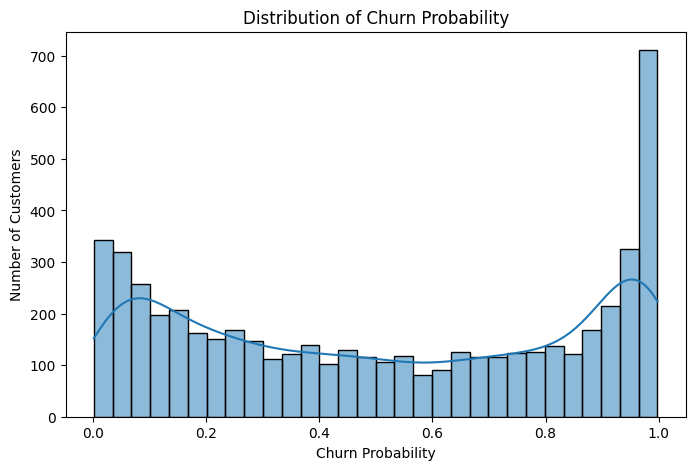

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(
    data=df_pred_15,
    x="churn_proba",
    bins=30,
    kde=True
)

plt.xlabel("Churn Probability")
plt.ylabel("Number of Customers")
plt.title("Distribution of Churn Probability")
plt.show()


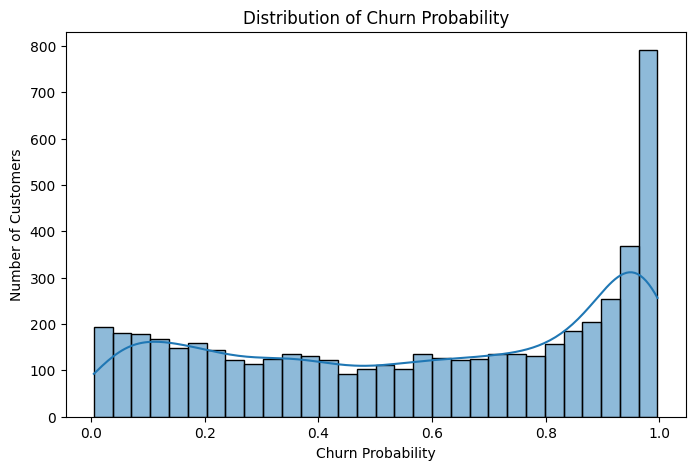

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(
    data=df_pred_30,
    x="churn_proba",
    bins=30,
    kde=True
)

plt.xlabel("Churn Probability")
plt.ylabel("Number of Customers")
plt.title("Distribution of Churn Probability")
plt.show()

In [77]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# plt.figure(figsize=(8,5))
# sns.histplot(
#     data=df_pred_45,
#     x="churn_proba",
#     bins=30,
#     kde=True
# )

# plt.xlabel("Churn Probability")
# plt.ylabel("Number of Customers")
# plt.title("Distribution of Churn Probability")
# plt.show()